**Rules for the code:**

- Include all the code you used for your report in this file. The code for any section in the report should go under the same section in this file.
- Any missing code will result in -20% from its corresponding section in the report.
- Any irrelevant code will result in -20% from its corresponding section in the report.
- Make sure that you run your code before rendering, so all the necessary visual/numeric outputs are visible.
- Any code that is not properly run or throws errors will be considered missing/irrelevant.

In [124]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [125]:
health_data = pd.read_csv('lifestyle_data.csv')
health_data

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,46.77,Female,98.31,1.90,199.20,148.18,63.72,0.77,761.61,Strength,...,1882.80,0.500000,0.954837,0.623413,0.743876,1865.39,71.269345,533.2558,7.924402e+19,Medium
19996,40.38,Female,88.12,1.87,196.18,134.18,54.04,1.97,2303.13,Strength,...,1205.47,0.496968,0.689060,0.563810,0.683964,173.87,65.049689,1310.6016,5.708474e+19,Low
19997,50.31,Male,46.20,1.67,163.34,157.92,61.65,1.36,1468.80,Strength,...,1947.79,0.500280,2.105844,0.946701,0.966818,-43.80,35.420708,957.9568,9.101285e+19,High
19998,52.36,Male,44.30,1.62,179.27,121.23,60.88,1.41,929.75,Yoga,...,1921.51,0.499940,2.190745,0.509756,0.676243,346.25,35.889260,928.4004,5.246436e+19,Low


## 3) Data

In [127]:
# Number of observations and columns
print(health_data.shape)

# Number of numeric and non-numeric columns
print((health_data.dtypes == "object").value_counts())

# Number of missing values
print(health_data.isnull().sum())

(20000, 54)
False    39
True     15
Name: count, dtype: int64
Age                               0
Gender                            0
Weight (kg)                       0
Height (m)                        0
Max_BPM                           0
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                   0
Workout_Type                      0
Fat_Percentage                    0
Water_Intake (liters)             0
Workout_Frequency (days/week)     0
Experience_Level                  0
BMI                               0
Daily meals frequency             0
Physical exercise                 0
Carbs                             0
Proteins                          0
Fats                              0
Calories                          0
meal_name                         0
meal_type                         0
diet_type                         0
sugar_g                           0
sodium_mg                         0
ch

## 5) Data Cleaning 

### a) Cleaning - Question 1

#### Outliers

In [131]:
# Outliers of protein
Q1 = np.percentile(health_data['Proteins'], 25)
Q3 = np.percentile(health_data['Proteins'], 75)

IQR = Q3 - Q1 

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

health_data.loc[(health_data['Proteins'] > upper_fence) | (health_data['Proteins'] < lower_fence), :].shape

(403, 54)

In [132]:
# Outliers of carbs
Q1 = np.percentile(health_data['Carbs'], 25)
Q3 = np.percentile(health_data['Carbs'], 75)

IQR = Q3 - Q1 

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

health_data.loc[(health_data['Carbs'] > upper_fence) | (health_data['Carbs'] < lower_fence), :].shape

(405, 54)

In [133]:
# Outliers of fats
Q1 = np.percentile(health_data['Fats'], 25)
Q3 = np.percentile(health_data['Fats'], 75)

IQR = Q3 - Q1 

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

health_data.loc[(health_data['Fats'] > upper_fence) | (health_data['Fats'] < lower_fence), :].shape

(399, 54)

In [134]:
# Outliers of calories burned per 30 minutes of exercise
Q1 = np.percentile(health_data['Burns Calories (per 30 min)'], 25)
Q3 = np.percentile(health_data['Burns Calories (per 30 min)'], 75)

IQR = Q3 - Q1 

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

health_data.loc[(health_data['Burns Calories (per 30 min)'] > upper_fence) | (health_data['Burns Calories (per 30 min)'] < lower_fence), :].shape

(893, 54)

In [135]:
# Outliers of session duration in hours
Q1 = np.percentile(health_data['Session_Duration (hours)'], 25)
Q3 = np.percentile(health_data['Session_Duration (hours)'], 75)

IQR = Q3 - Q1 

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

health_data.loc[(health_data['Session_Duration (hours)'] > upper_fence) | (health_data['Session_Duration (hours)'] < lower_fence), :].shape

(0, 54)

#### Categorical Variables

In [137]:
# Categories
display(health_data['diet_type'].unique())
display(health_data['diet_type'].value_counts())

print('--------------')

display(health_data['Gender'].unique())
display(health_data['Gender'].value_counts())

array(['Vegan', 'Vegetarian', 'Paleo', 'Keto', 'Low-Carb', 'Balanced'],
      dtype=object)

diet_type
Paleo         3403
Low-Carb      3379
Vegetarian    3337
Keto          3324
Vegan         3323
Balanced      3234
Name: count, dtype: int64

--------------


array(['Male', 'Female'], dtype=object)

Gender
Female    10028
Male       9972
Name: count, dtype: int64

#### Incorrect Values

In [139]:
health_data[(health_data['Proteins'] <= 0) | (health_data['Fats'] <= 0) | (health_data['Carbs'] <= 0) | (health_data['Session_Duration (hours)'] <= 0) | (health_data['Burns Calories (per 30 min)'] <= 0)] 
    # empty output -- no values less than or equal to 0

health_data['Proteins'].max() # 185.34 -- realistic for athletes
health_data['Fats'].max() # 123.42 -- realistic for people prioritizing high fat
health_data['Carbs'].max() # 462.49 -- realistic for people prioritizing high carb

health_data['Session_Duration (hours)'].min() # 0.49 -- realistic workout duration
health_data['Session_Duration (hours)'].max() # 2.02 -- realistic  workout duration

health_data['Burns Calories (per 30 min)'].min() # 128.75 -- realistic caloric burn for 30 mins of exercise
health_data['Burns Calories (per 30 min)'].max() # 381.71 -- realistic for high intensity exercise

381.71

### b) Cleaning - Question 2


#### Outliers

In [142]:
# Outliers of Fat percentage
Q1 = np.percentile(health_data['Fat_Percentage'], 25)
Q3 = np.percentile(health_data['Fat_Percentage'], 75)

IQR = Q3 - Q1 

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

health_data.loc[(health_data['Fat_Percentage'] > upper_fence) | (health_data['Fat_Percentage'] < lower_fence), :].shape

(1, 54)

In [143]:
# Outliers of Workout_Frequency (days/week)
Q1 = np.percentile(health_data['Workout_Frequency (days/week)'], 25)
Q3 = np.percentile(health_data['Workout_Frequency (days/week)'], 75)

IQR = Q3 - Q1 

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

health_data.loc[(health_data['Workout_Frequency (days/week)'] > upper_fence) | (health_data['Workout_Frequency (days/week)'] < lower_fence), :].shape

(0, 54)

In [144]:
# Outliers of BMI
Q1 = np.percentile(health_data['BMI'], 25)
Q3 = np.percentile(health_data['BMI'], 75)

IQR = Q3 - Q1 

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

health_data.loc[(health_data['BMI'] > upper_fence) | (health_data['BMI'] < lower_fence), :].shape

(530, 54)

In [145]:
# Outliers of resting heart rate
Q1 = np.percentile(health_data['Resting_BPM'], 25)
Q3 = np.percentile(health_data['Resting_BPM'], 75)

IQR = Q3 - Q1 

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

health_data.loc[(health_data['Resting_BPM'] > upper_fence) | (health_data['Resting_BPM'] < lower_fence), :].shape

(0, 54)

In [146]:
# Outliers of experience level
Q1 = np.percentile(health_data['Experience_Level'], 25)
Q3 = np.percentile(health_data['Experience_Level'], 75)

IQR = Q3 - Q1 

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

health_data.loc[(health_data['Experience_Level'] > upper_fence) | (health_data['Experience_Level'] < lower_fence), :].shape

(0, 54)

#### Categorical Variables

In [148]:
display(health_data['Gender'].unique())
display(health_data['Gender'].value_counts())

array(['Male', 'Female'], dtype=object)

Gender
Female    10028
Male       9972
Name: count, dtype: int64

#### Incorrect Values

In [150]:
health_data['Resting_BPM'].min() # 49.49 BPM -- realistic resting heart rate for an established athlete
health_data['Resting_BPM'].max() # 74.5 BPM -- realistic resting heart rate

health_data['Experience_Level'].min() # 1 -- minimum value is contained within the 1 - 3.05 range
health_data['Experience_Level'].max() # 3.05 -- maximum value is contained within the 1 - 3.05 renage

health_data['Workout_Frequency (days/week)'].min() # 1.94 -- realistic, not negative
health_data['Workout_Frequency (days/week)'].max() # 5.06 -- realistic, not above 7

health_data['Fat_Percentage'].min() # 11.1% -- realistic
health_data['Fat_Percentage'].max() # 35% -- realistic

health_data['BMI'].min() # 12.04 -- WAY TOO LOW: IMPOSSIBLE
health_data['BMI'].max() # 50.23 -- is still possible. will keep to include as much variation in individuals as possible

50.23

In [151]:
# Filtering out observations with BMI < 16
bmi_filtered_q2 = health_data.copy()
bmi_filtered_q2 = health_data[health_data['BMI'] > 16]

bmi_filtered_q2['BMI'].min() # min is now 16.01 instead of  12.04
bmi_filtered_q2.shape

(18547, 54)

### c) Cleaning - Question 3

#### Outliers

In [154]:
# Outliers of total calories burned
Q1 = np.percentile(health_data['Calories_Burned'], 25)
Q3 = np.percentile(health_data['Calories_Burned'], 75)

IQR = Q3 - Q1 

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

health_data.loc[(health_data['Calories_Burned'] > upper_fence) | (health_data['Calories_Burned'] < lower_fence), :].shape

(507, 54)

#### Categorical Variables

In [156]:
display(health_data['Gender'].unique())
display(health_data['Gender'].value_counts())

print('--------------')
display(health_data['Workout_Type'].unique())
display(health_data['Workout_Type'].value_counts())

array(['Male', 'Female'], dtype=object)

Gender
Female    10028
Male       9972
Name: count, dtype: int64

--------------


array(['Strength', 'HIIT', 'Cardio', 'Yoga'], dtype=object)

Workout_Type
Strength    5071
Yoga        5032
HIIT        4974
Cardio      4923
Name: count, dtype: int64

#### Incorrect Values

In [158]:
health_data['Age'].min() # 18 years old
health_data['Calories_Burned'].min() # 323.11 -- NOT POSSIBLE IF MINIMUM AGE IS 18
health_data['Calories_Burned'].max() # 2890 -- possible for an athlete

calories_filtered_q3 = health_data[health_data['Calories_Burned'] >= 1000]

calories_filtered_q3['Calories_Burned'].min() # 1000.06 -- filtered
calories_filtered_q3['Calories_Burned'].shape

(13420,)

## 6) Data Analysis

### a) Analysis 1

#### Average Macronutrient Intake and its Relationship on Average Workout Duration in Hours

In [162]:
# Finding the percentage of calories for each macronutrient out of the total calorie intake
health_data['Protein_pct'] = (health_data['Proteins'] * 4) / health_data['Calories'] * 100 # 1g of protein is 4 calories
health_data['Carb_pct'] = (health_data['Carbs'] * 4) / health_data['Calories'] * 100 # 1g of carb is 4 calories
health_data['Fat_pct'] = (health_data['Fats'] * 9) / health_data['Calories'] * 100 # 1g of fat is 9 calories

# Creating the thresholds of macronutrients based on acceptable macronutrient distribution ranges (AMDRs)
protein_bins = [0, 10, 35, np.inf]
carb_bins = [0, 45, 65, np.inf]
fat_bins = [0, 20, 35, np.inf]

labels = ['Low', 'Moderate', 'High']

# Creating the bins 
health_data['Protein_Bin'] = pd.cut(health_data['Protein_pct'], bins = protein_bins, labels = labels, include_lowest = True)
health_data['Carb_Bin'] = pd.cut(health_data['Carb_pct'], bins = carb_bins, labels = labels, include_lowest = True)
health_data['Fat_Bin'] = pd.cut(health_data['Fat_pct'], bins = fat_bins, labels = labels, include_lowest = True)

In [163]:
# Thresholds for each macronutrient (to display in report)
pd.DataFrame({
    "Macronutrient": ["Protein", "Carbs", "Fats"],
    "Low–Moderate Threshold": [protein_bins[1], carb_bins[1], fat_bins[1]],
    "Moderate–High Threshold": [protein_bins[2], carb_bins[2], fat_bins[2]]})

,Macronutrient,Low–Moderate Threshold,Moderate–High Threshold
0,Protein,10,35
1,Carbs,45,65
2,Fats,20,35


In [164]:
# Number of observations for each bin (to display in report)
pd.DataFrame({
    "Low Intake Count": [
        health_data['Protein_Bin'].value_counts().get("Low", 0),
        health_data['Carb_Bin'].value_counts().get("Low", 0),
        health_data['Fat_Bin'].value_counts().get("Low", 0)],
    "Moderate Intake Count": [
        health_data['Protein_Bin'].value_counts().get("Moderate", 0),
        health_data['Carb_Bin'].value_counts().get("Moderate", 0),
        health_data['Fat_Bin'].value_counts().get("Moderate", 0)],
    "High Intake Count": [
        health_data['Protein_Bin'].value_counts().get("High", 0),
        health_data['Carb_Bin'].value_counts().get("High", 0),
        health_data['Fat_Bin'].value_counts().get("High", 0)]}, 
    index = ["Protein", "Carbs", "Fats"]).reset_index().rename(columns = {"index": "Macronutrient"})

,Macronutrient,Low Intake Count,Moderate Intake Count,High Intake Count
0,Protein,350,18755,895
1,Carbs,7695,7789,4516
2,Fats,2434,11026,6540


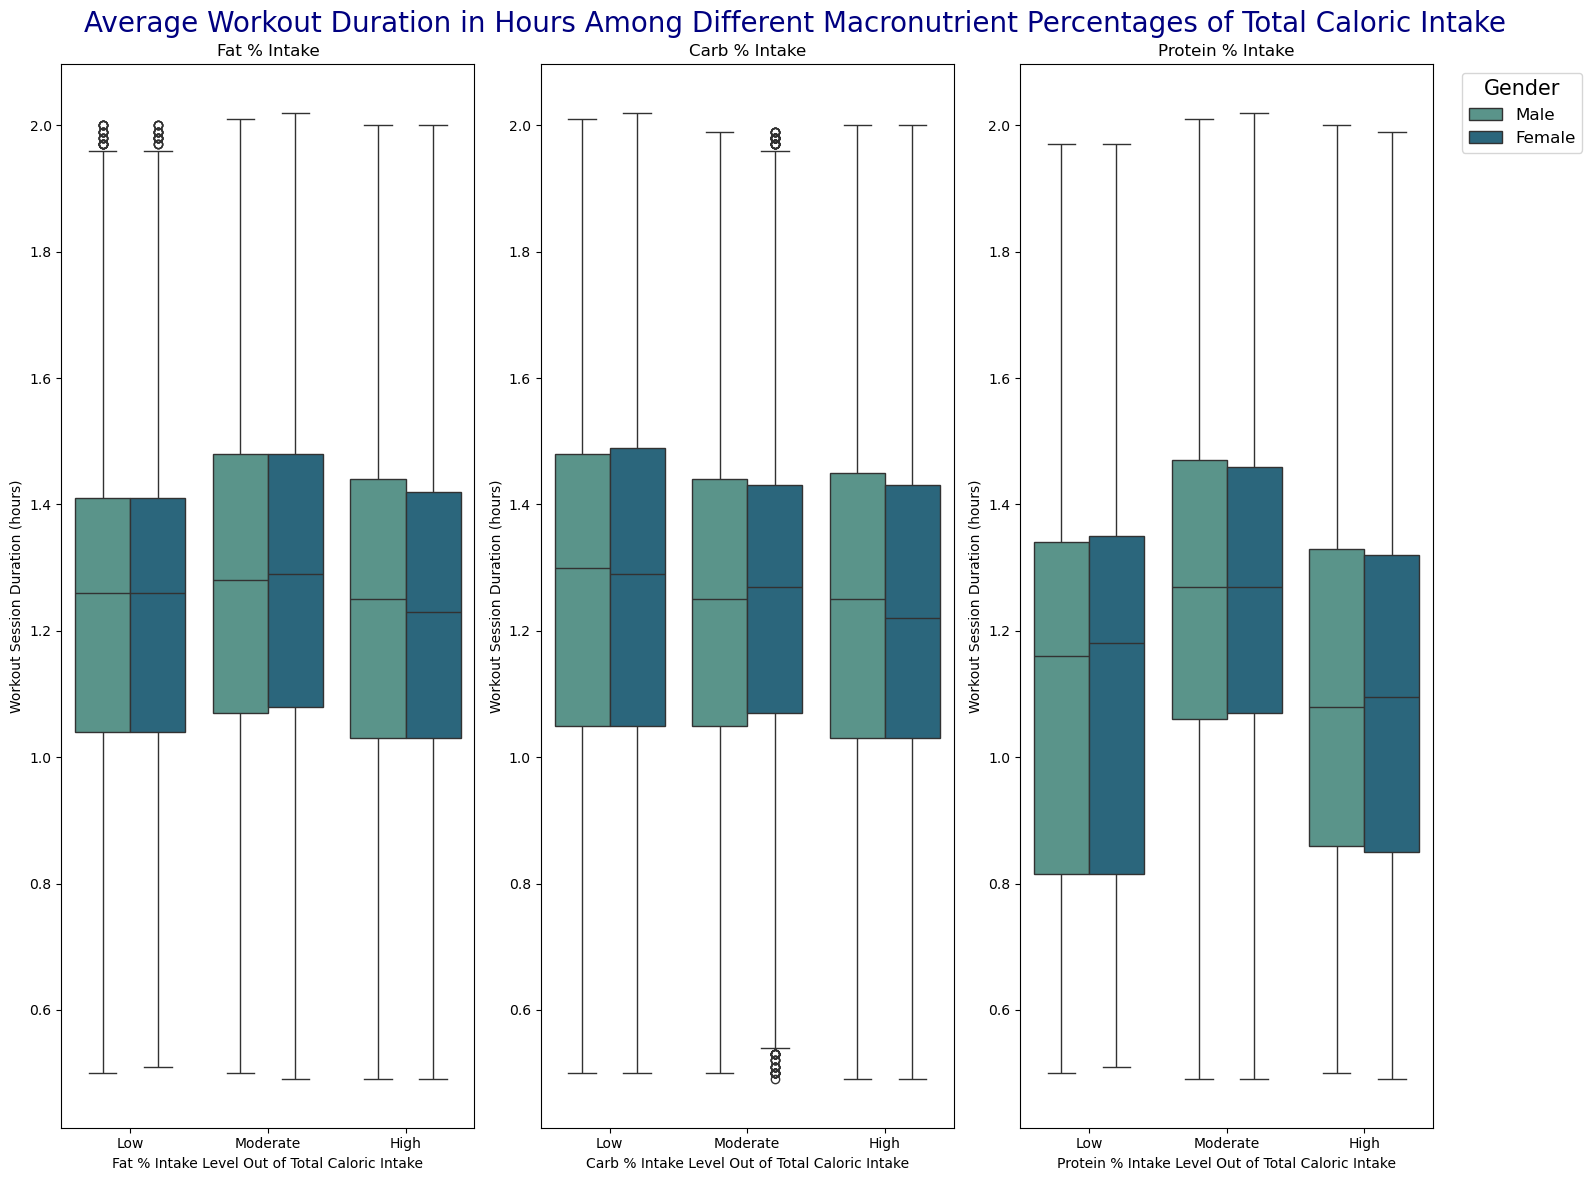

In [165]:

# Creating the visualization: 1x3 subplot 
plt.figure(figsize=(16, 12))

    # Fats and Calories Burned per 30 minutes of exercise plot
plt.subplot(1,3,1)
sns.boxplot(data = health_data, x = 'Fat_Bin', y = 'Session_Duration (hours)', hue = 'Gender', palette = 'crest')
plt.title("Fat % Intake")
plt.xlabel("Fat % Intake Level Out of Total Caloric Intake")
plt.ylabel("Workout Session Duration (hours)")
plt.legend([],[], frameon = False)   # remove local legend


    # Carbs and Calories Burned per 30 minutes of exercise plot
plt.subplot(1,3,2)
sns.boxplot(data = health_data, x = 'Carb_Bin', y = 'Session_Duration (hours)', hue = 'Gender', palette = 'crest')
plt.title("Carb % Intake")
plt.xlabel("Carb % Intake Level Out of Total Caloric Intake")
plt.ylabel("Workout Session Duration (hours)")
plt.legend([],[], frameon = False) # remove local legend


    # Carbs and Calories Burned per 30 minutes of exercise plot
plt.subplot(1,3,3)
sns.boxplot(data = health_data, x = 'Protein_Bin', y = 'Session_Duration (hours)', hue = 'Gender', palette = 'crest')
plt.title("Protein % Intake")
plt.xlabel("Protein % Intake Level Out of Total Caloric Intake")
plt.ylabel("Workout Session Duration (hours)")
plt.legend([],[], frameon = False)

    # Creating a global legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, title = "Gender", bbox_to_anchor = (1.05, 1), loc = "upper left", title_fontsize = 15, fontsize = 12)


plt.suptitle('Average Workout Duration in Hours Among Different Macronutrient Percentages of Total Caloric Intake', fontsize = 20, color = 'navy')
plt.tight_layout()
plt.show()


In [166]:
# Summary table of the boxplot above for each macronutrient to display in report
    # Protein
summary = health_data.groupby(['Protein_Bin', 'Gender'])['Session_Duration (hours)'].agg(
    count = 'count',
    mean = 'mean',
    median = 'median',
    q1 = lambda x: x.quantile(0.25),
    q3=  lambda x: x.quantile(0.75))

summary['IQR'] = summary['q3'] - summary['q1']

def outlier_count(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((x < lower) | (x > upper)).sum()

summary['outliers'] = health_data.groupby(['Protein_Bin', 'Gender'])['Session_Duration (hours)'].apply(outlier_count)
summary = summary.reset_index() 
summary = summary.rename(columns = {'Protein_Bin': 'Protein % Intake'}) # renaming the column to be more readable in report
display(summary)


    # Carbs
summary = health_data.groupby(['Carb_Bin', 'Gender'])['Session_Duration (hours)'].agg(
    count = 'count',
    mean = 'mean',
    median = 'median',
    q1 = lambda x: x.quantile(0.25),
    q3=  lambda x: x.quantile(0.75))

summary['IQR'] = summary['q3'] - summary['q1']

summary['outliers'] = health_data.groupby(['Carb_Bin', 'Gender'])['Session_Duration (hours)'].apply(outlier_count)
summary = summary.reset_index() 
summary = summary.rename(columns = {'Carb_Bin': 'Carb % Intake'})
display(summary)


    # Fats
summary = health_data.groupby(['Fat_Bin', 'Gender'])['Session_Duration (hours)'].agg(
    count = 'count',
    mean = 'mean',
    median = 'median',
    q1 = lambda x: x.quantile(0.25),
    q3=  lambda x: x.quantile(0.75))

summary['IQR'] = summary['q3'] - summary['q1']

summary['outliers'] = health_data.groupby(['Fat_Bin', 'Gender'])['Session_Duration (hours)'].apply(outlier_count)
summary = summary.reset_index() 
summary = summary.rename(columns = {'Fat_Bin': 'Fat % Intake'})
display(summary)

,Protein % Intake,Gender,count,mean,median,q1,q3,IQR,outliers
0,Low,Female,175,1.109543,1.180,0.815,1.35,0.535,0
1,Low,Male,175,1.113714,1.160,0.815,1.34,0.525,0
2,Moderate,Female,9391,1.270229,1.270,1.070,1.46,0.390,0
3,Moderate,Male,9364,1.269620,1.270,1.060,1.47,0.410,0
4,High,Female,462,1.097056,1.095,0.850,1.32,0.470,0
5,High,Male,433,1.098337,1.080,0.860,1.33,0.470,0


,Carb % Intake,Gender,count,mean,median,q1,q3,IQR,outliers
0,Low,Female,3857,1.285725,1.29,1.05,1.49,0.44,0
1,Low,Male,3838,1.286352,1.30,1.05,1.48,0.43,0
2,Moderate,Female,3875,1.258080,1.27,1.07,1.43,0.36,75
3,Moderate,Male,3914,1.244223,1.25,1.05,1.44,0.39,0
4,High,Female,2296,1.217609,1.22,1.03,1.43,0.40,0
5,High,Male,2220,1.239770,1.25,1.03,1.45,0.42,0


,Fat % Intake,Gender,count,mean,median,q1,q3,IQR,outliers
0,Low,Female,1223,1.237244,1.26,1.04,1.41,0.37,20
1,Low,Male,1211,1.243518,1.26,1.04,1.41,0.37,26
2,Moderate,Female,5486,1.285684,1.29,1.08,1.48,0.40,0
3,Moderate,Male,5540,1.276812,1.28,1.07,1.48,0.41,0
4,High,Female,3319,1.224260,1.23,1.03,1.42,0.39,0
5,High,Male,3221,1.235567,1.25,1.03,1.44,0.41,0


#### Average Macronutrient Intake and Calories Burned in 30 Minutes of Exercise for Different Diets

In [168]:
# Grouping the data
grouped_data = health_data.groupby(['diet_type', 'Gender']).agg(
    mean_protein_intake = ('Proteins', 'mean'),
    mean_carb_intake = ('Carbs', 'mean'),
    mean_fat_intake = ('Fats', 'mean'),
    mean_calories_burned_workout = ('Burns Calories (per 30 min)', 'mean')).reset_index()

grouped_data = grouped_data.rename(columns = {'diet_type':'Diet Type'})

grouped_data

,Diet Type,Gender,mean_protein_intake,mean_carb_intake,mean_fat_intake,mean_calories_burned_workout
0,Balanced,Female,101.019981,252.479553,67.345447,344.267084
1,Balanced,Male,99.416813,248.505364,66.271455,345.251486
2,Keto,Female,99.318822,248.298408,66.214548,344.028484
3,Keto,Male,99.414525,248.532063,66.287738,344.492958
4,Low-Carb,Female,100.972185,252.387213,67.312029,344.841740
5,Low-Carb,Male,100.567625,251.410815,67.046607,344.183906
6,Paleo,Female,99.844501,249.595756,66.549019,343.935960
7,Paleo,Male,100.262154,250.600349,66.840402,343.471183
8,Vegan,Female,99.344563,248.371788,66.230547,343.159513
9,Vegan,Male,99.198695,247.991366,66.136793,343.663085


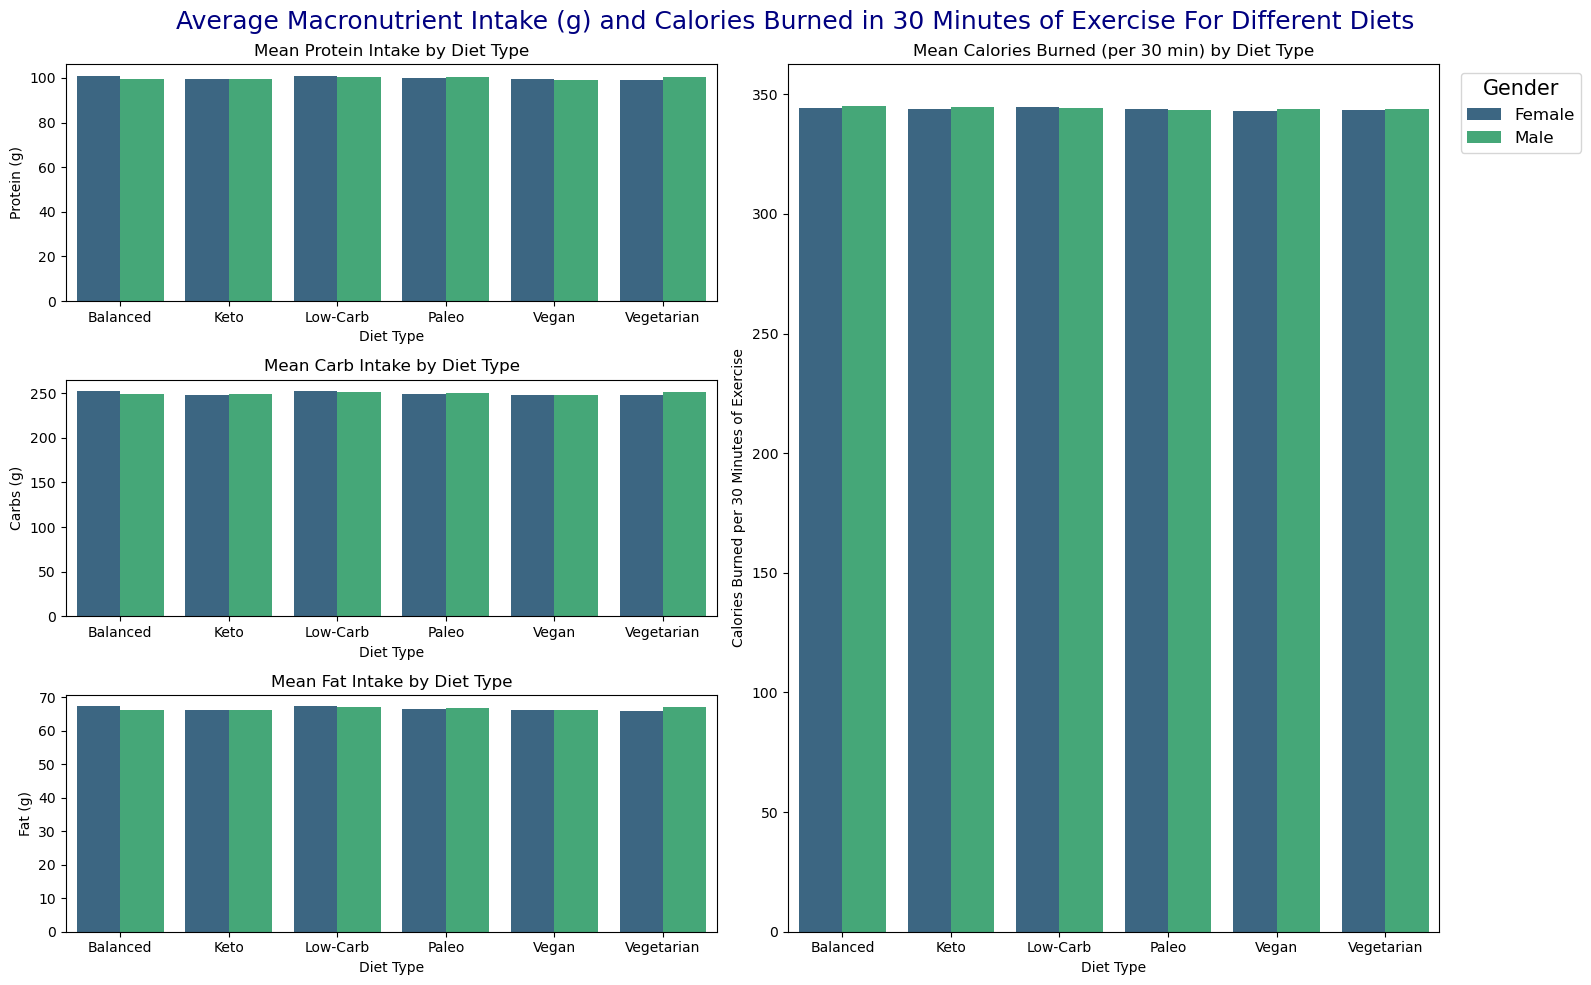

In [169]:
# Graph using GridSpec layout for each subplot -- this allowed for more control on how to layout the plots

from matplotlib.gridspec import GridSpec
plt.figure(figsize = (16, 10))

gs = GridSpec(3, 4)

    # Protein
plt.subplot(gs[0, 0:2])   # row 0, columns 0–1
sns.barplot(data = grouped_data, x = 'Diet Type', y = 'mean_protein_intake', hue = 'Gender', palette = 'viridis')
plt.title("Mean Protein Intake by Diet Type")
plt.xlabel("Diet Type")
plt.ylabel("Protein (g)")
plt.legend([], [], frameon=False)

    # Carbs
plt.subplot(gs[1, 0:2])   # row 1, columns 0–1
sns.barplot(data = grouped_data, x = 'Diet Type', y = 'mean_carb_intake', hue = 'Gender', palette = 'viridis')
plt.title("Mean Carb Intake by Diet Type")
plt.xlabel("Diet Type")
plt.ylabel("Carbs (g)")
plt.legend([], [], frameon=False)

    # Fats
plt.subplot(gs[2, 0:2])   # row 2, columns 0–1
sns.barplot( data = grouped_data, x = 'Diet Type', y = 'mean_fat_intake', hue = 'Gender', palette = 'viridis')
plt.title("Mean Fat Intake by Diet Type")
plt.xlabel("Diet Type")
plt.ylabel("Fat (g)")
plt.legend([], [], frameon=False)

    # Mean Calories Burned per Diet Type (larger plot -- more emphasis)
plt.subplot(gs[:, 2:4])  # all rows (:), columns 2–3
sns.barplot(data = grouped_data, x = 'Diet Type', y = 'mean_calories_burned_workout', hue = 'Gender', palette = 'viridis')
plt.title("Mean Calories Burned (per 30 min) by Diet Type")
plt.xlabel("Diet Type")
plt.ylabel("Calories Burned per 30 Minutes of Exercise")

# Creating a global legend for gender
plt.legend(title = "Gender", title_fontsize = 15, fontsize = 12, bbox_to_anchor = (1.02, 1), loc = "upper left")

plt.suptitle('Average Macronutrient Intake (g) and Calories Burned in 30 Minutes of Exercise For Different Diets', fontsize = 18, color = 'navy')
plt.tight_layout()
plt.show()


In [170]:
# Summary table: mean, median, count for each diet-gender combination to display in report
summary_table = (health_data.groupby(['diet_type', 'Gender']).agg(
        protein_mean = ('Proteins', 'mean'),
        protein_median = ('Proteins', 'median'),

        carb_mean = ('Carbs', 'mean'),
        carb_median = ('Carbs', 'median'),

        fat_mean = ('Fats', 'mean'),
        fat_median = ('Fats', 'median'),

        calories_burned_mean = ('Burns Calories (per 30 min)', 'mean'),
        calories_burned_median = ('Burns Calories (per 30 min)', 'median'),
        
        total_count = ('diet_type', 'count')).reset_index())

summary_table

,diet_type,Gender,protein_mean,protein_median,carb_mean,carb_median,fat_mean,fat_median,calories_burned_mean,calories_burned_median,total_count
0,Balanced,Female,101.019981,98.070,252.479553,245.130,67.345447,65.330,344.267084,348.830,1612
1,Balanced,Male,99.416813,96.180,248.505364,239.820,66.271455,64.110,345.251486,349.385,1622
2,Keto,Female,99.318822,96.250,248.298408,240.690,66.214548,64.310,344.028484,348.160,1715
3,Keto,Male,99.414525,97.100,248.532063,243.040,66.287738,64.640,344.492958,347.870,1609
4,Low-Carb,Female,100.972185,97.670,252.387213,244.190,67.312029,65.220,344.841740,349.100,1661
5,Low-Carb,Male,100.567625,98.275,251.410815,245.665,67.046607,65.415,344.183906,348.235,1718
6,Paleo,Female,99.844501,96.910,249.595756,242.200,66.549019,64.580,343.935960,348.060,1713
7,Paleo,Male,100.262154,97.520,250.600349,243.600,66.840402,64.985,343.471183,348.820,1690
8,Vegan,Female,99.344563,96.850,248.371788,241.780,66.230547,64.540,343.159513,348.080,1683
9,Vegan,Male,99.198695,96.595,247.991366,241.450,66.136793,64.465,343.663085,349.385,1640


### c) Analysis 2 

#### Analyzing Relationship Between Workout Experience Level and BMI

In [173]:
# Creating bins
bins = [1.0, 2.0, 3.0, bmi_filtered_q2['Experience_Level'].max()]
labels = ['Beginner', 'Intermediate', 'Advanced']

exp_cat, exp_bins = pd.cut(bmi_filtered_q2['Experience_Level'], bins = bins, labels = labels, include_lowest = True, retbins = True)
bmi_filtered_q2['Experience_Bin'] = exp_cat
 
# Creating table to display in project
experience_bin_table = pd.DataFrame({
    'Workout Experience Level': labels,
    'Experience Level Range': [
        f"{bins[0]} – {bins[1]}",
        f"{bins[1]} – {bins[2]}",
        f"{bins[2]} – {bins[3]:.2f}"],
    'Number of Observations': bmi_filtered_q2['Experience_Bin'].value_counts().loc[labels].values})

display(experience_bin_table)

,Workout Experience Level,Experience Level Range,Number of Observations
0,Beginner,1.0 – 2.0,11912
1,Intermediate,2.0 – 3.0,5215
2,Advanced,3.0 – 3.05,1420


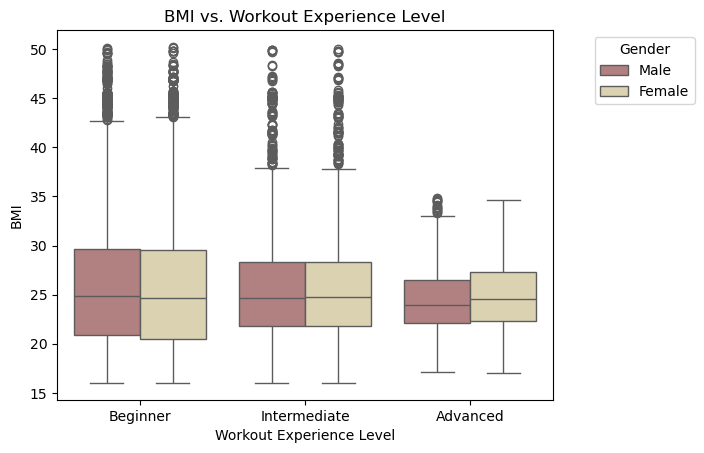

In [174]:
# BMI vs. Workout Experience Level plot

sns.boxplot(data = bmi_filtered_q2, x = 'Experience_Bin', y = 'BMI', hue = 'Gender', palette = 'pink')
plt.xlabel('Workout Experience Level')
plt.ylabel('BMI')
plt.title('BMI vs. Workout Experience Level')
plt.legend(bbox_to_anchor = (1.3,1), title = 'Gender')
plt.show()

In [175]:
# Table containing information of the boxplot above

def outlier_count(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((x < lower) | (x > upper)).sum()


summary = bmi_filtered_q2.groupby(['Experience_Bin', 'Gender'])['BMI'].agg(
    count = 'count',
    mean = 'mean',
    median = 'median',
    q1 = lambda x: x.quantile(0.25),
    q3 = lambda x: x.quantile(0.75)).reset_index()

summary['IQR'] = summary['q3'] - summary['q1']

summary['Outliers'] = (bmi_filtered_q2.groupby(['Experience_Bin', 'Gender'])['BMI'].apply(outlier_count).values)
summary = summary.rename(columns = {'Experience_Bin': 'Experience Level'})

summary


,Experience Level,Gender,count,mean,median,q1,q3,IQR,Outliers
0,Beginner,Female,5938,25.736750,24.62,20.5100,29.5475,9.0375,143
1,Beginner,Male,5974,25.965405,24.82,20.8925,29.6250,8.7325,169
2,Intermediate,Female,2653,25.709778,24.79,21.8200,28.3300,6.5100,101
3,Intermediate,Male,2562,25.691819,24.68,21.8100,28.3175,6.5075,102
4,Advanced,Female,692,24.991373,24.54,22.3550,27.3500,4.9950,0
5,Advanced,Male,728,24.582088,23.98,22.1300,26.5100,4.3800,15


In [176]:
# Table to display in project
    # (same table as above, just to reiterate the thresholds and number of observations in each group)
experience_bin_table = pd.DataFrame({
    'Workout Experience Level': labels,
    'Experience Level Range': [
        f"{bins[0]} – {bins[1]}",
        f"{bins[1]} – {bins[2]}",
        f"{bins[2]} – {bins[3]:.2f}"],
    'Number of Observations': bmi_filtered_q2['Experience_Bin'].value_counts().loc[labels].values})

display(experience_bin_table)

,Workout Experience Level,Experience Level Range,Number of Observations
0,Beginner,1.0 – 2.0,11912
1,Intermediate,2.0 – 3.0,5215
2,Advanced,3.0 – 3.05,1420


#### Analyzing Relationship Between Workout Experience Level and Body Fat Percentage

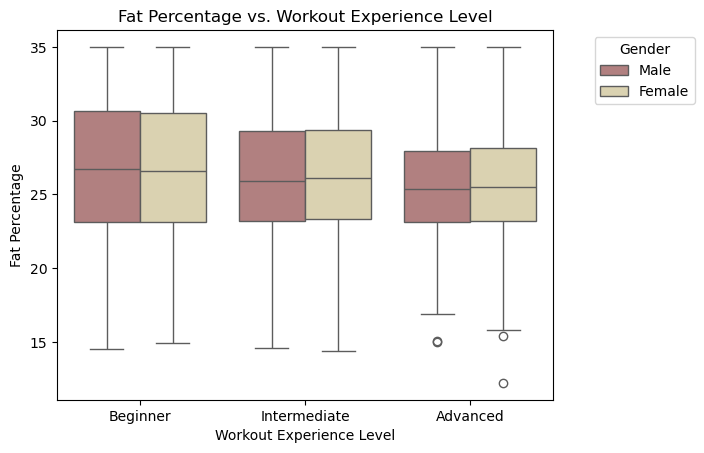

In [178]:
# Fat Percentage vs. Workout Experience Level plot
sns.boxplot(data = bmi_filtered_q2, x = 'Experience_Bin', y = 'Fat_Percentage', hue = 'Gender', palette = 'pink')
plt.xlabel('Workout Experience Level')
plt.ylabel('Fat Percentage')
plt.title('Fat Percentage vs. Workout Experience Level')
plt.legend(bbox_to_anchor = (1.3,1), title = 'Gender')
plt.show()

In [179]:
# Table containing information of the boxplot above
summary = bmi_filtered_q2.groupby(['Experience_Bin', 'Gender'])['Fat_Percentage'].agg(
    count = 'count',
    mean = 'mean',
    median = 'median',
    q1 = lambda x: x.quantile(0.25),
    q3 = lambda x: x.quantile(0.75)).reset_index()

summary['IQR'] = summary['q3'] - summary['q1']

summary['Outliers'] = (bmi_filtered_q2.groupby(['Experience_Bin', 'Gender'])['Fat_Percentage'].apply(outlier_count).values)
summary = summary.rename(columns = {'Experience_Bin': 'Experience Level'})

summary

,Experience Level,Gender,count,mean,median,q1,q3,IQR,Outliers
0,Beginner,Female,5938,26.870315,26.596755,23.104323,30.517200,7.412877,0
1,Beginner,Male,5974,27.016155,26.729580,23.131270,30.635247,7.503977,0
2,Intermediate,Female,2653,26.503088,26.129580,23.357447,29.377557,6.020110,0
3,Intermediate,Male,2562,26.386367,25.908383,23.223487,29.308319,6.084831,0
4,Advanced,Female,692,25.722618,25.535387,23.181872,28.132323,4.950451,2
5,Advanced,Male,728,25.673748,25.402983,23.150111,27.943975,4.793864,2


#### The Relationship Between Resting Heart Rate and Workout Frequency

In [181]:
# Workout Frequency and resting heart rate analysis
bins = [0,2,4,7]
labels = ['Low Frequency', 'Moderate Frequency', 'High Frequency']

exp_cat, exp_bins = pd.cut(bmi_filtered_q2['Workout_Frequency (days/week)'], bins = bins, labels = labels, include_lowest = True, retbins = True)
bmi_filtered_q2['Frequency_Bin'] = exp_cat
 
# Create table to incorporate into report 
frequency_bin_table = pd.DataFrame({
    'Workout Frequency (days/week)': labels,
    'Workout Frequency Range': [
        f"{bins[0]} – {bins[1]}",
        f"{bins[1]} – {bins[2]}",
        f"{bins[2]} – {bins[3]:.2f}"],
    'Number of Observations': bmi_filtered_q2['Frequency_Bin'].value_counts().loc[labels].values})

display(frequency_bin_table)


,Workout Frequency (days/week),Workout Frequency Range,Number of Observations
0,Low Frequency,0 – 2,2309
1,Moderate Frequency,2 – 4,11872
2,High Frequency,4 – 7.00,4366


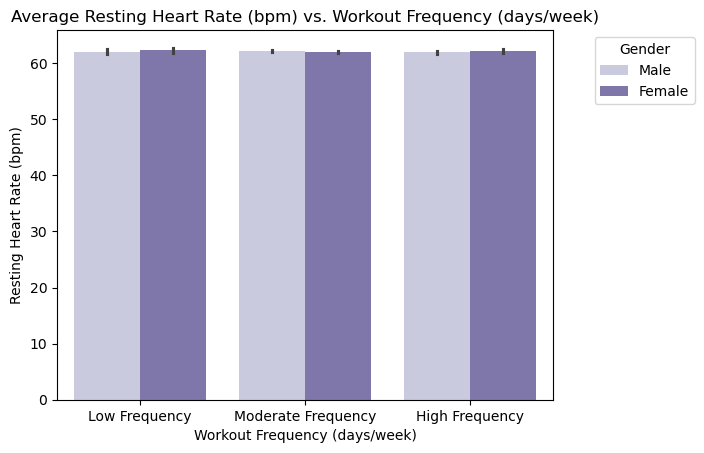

In [182]:
# Resting heart rate vs. workout frequency visualization
sns.barplot(data = bmi_filtered_q2, x = 'Frequency_Bin', y = 'Resting_BPM', hue = 'Gender', palette = 'Purples', estimator = 'mean')
plt.xlabel('Workout Frequency (days/week)')
plt.ylabel('Resting Heart Rate (bpm)')
plt.title('Average Resting Heart Rate (bpm) vs. Workout Frequency (days/week)')
plt.legend(bbox_to_anchor = (1.3,1), title = 'Gender')
plt.show()

In [183]:
# sns calculates the 95% confidence interval internally
    # so to display the numeric information in my report, I will calculate it manually

summary = bmi_filtered_q2.groupby(['Frequency_Bin', 'Gender'])['Resting_BPM'].agg(
    mean = 'mean',
    median = 'median',
    count = 'count',
    std = 'std').reset_index()

# Computing the 95% CI (looked up formula online)
summary['standard_error'] = summary['std'] / np.sqrt(summary['count'])
summary['CI_lower'] = summary['mean'] - 1.96 * summary['standard_error']
summary['CI_upper'] = summary['mean'] + 1.96 * summary['standard_error']

# Combining everything into one table
summary = summary[['Frequency_Bin','Gender','mean','median','count','CI_lower','CI_upper']]
summary = summary.rename(columns = {'Frequency_Bin': 'Workout Frequency'})
summary

,Workout Frequency,Gender,mean,median,count,CI_lower,CI_upper
0,Low Frequency,Female,62.295455,62.290,1186,61.867717,62.723193
1,Low Frequency,Male,62.028424,62.020,1123,61.587475,62.469373
2,Moderate Frequency,Female,62.037194,62.090,5906,61.854332,62.220057
3,Moderate Frequency,Male,62.222358,62.825,5966,62.041571,62.403146
4,High Frequency,Female,62.169051,62.040,2191,61.858347,62.479755
5,High Frequency,Male,61.902543,61.970,2175,61.588460,62.216625


### b) Analysis 3

#### Proportion of Observations of Each Diet Type per Workout Type

In [186]:
count_data = (calories_filtered_q3.groupby(['diet_type', 'Workout_Type']).size().reset_index(name = 'Observation Count'))
count_data['Proportion'] = count_data['Observation Count'] / count_data.groupby('diet_type')['Observation Count'].transform('sum')

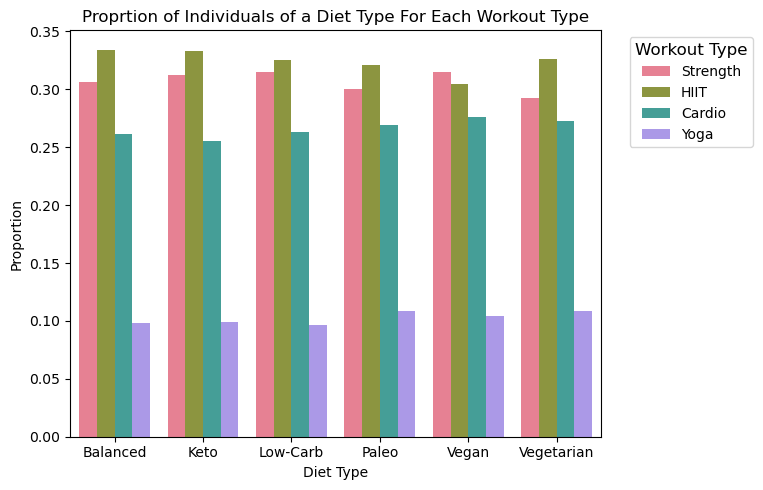

In [187]:
# Proportion bar plot
plt.figure(figsize = (8,5))
sns.barplot(data = count_data, x = 'diet_type', y = 'Proportion', hue = 'Workout_Type', palette = 'husl', hue_order = calories_filtered_q3['Workout_Type'].unique())
plt.title('Proprtion of Individuals of a Diet Type For Each Workout Type')
plt.xlabel('Diet Type')
plt.ylabel('Proportion')
plt.legend(bbox_to_anchor = (1.3,1), title = 'Workout Type', title_fontsize = 12)
plt.tight_layout()

plt.show()

In [188]:
# Table to include in my report that highlights the proportion and total observations for each group
count_data

,diet_type,Workout_Type,Observation Count,Proportion
0,Balanced,Cardio,565,0.261211
1,Balanced,HIIT,723,0.334258
2,Balanced,Strength,663,0.306519
3,Balanced,Yoga,212,0.098012
4,Keto,Cardio,577,0.255762
5,Keto,HIIT,752,0.333333
6,Keto,Strength,704,0.312057
7,Keto,Yoga,223,0.098848
8,Low-Carb,Cardio,593,0.262971
9,Low-Carb,HIIT,734,0.325499


#### Analyzing Total Calories Burned Per Diet Type and Workout Type

In [190]:
# Separating male and female data: males and females have different bodily needs that shouldn't be combined into one graph
male_cals_data = calories_filtered_q3[calories_filtered_q3['Gender'] == 'Male']
female_cals_data = calories_filtered_q3[calories_filtered_q3['Gender'] == 'Female']

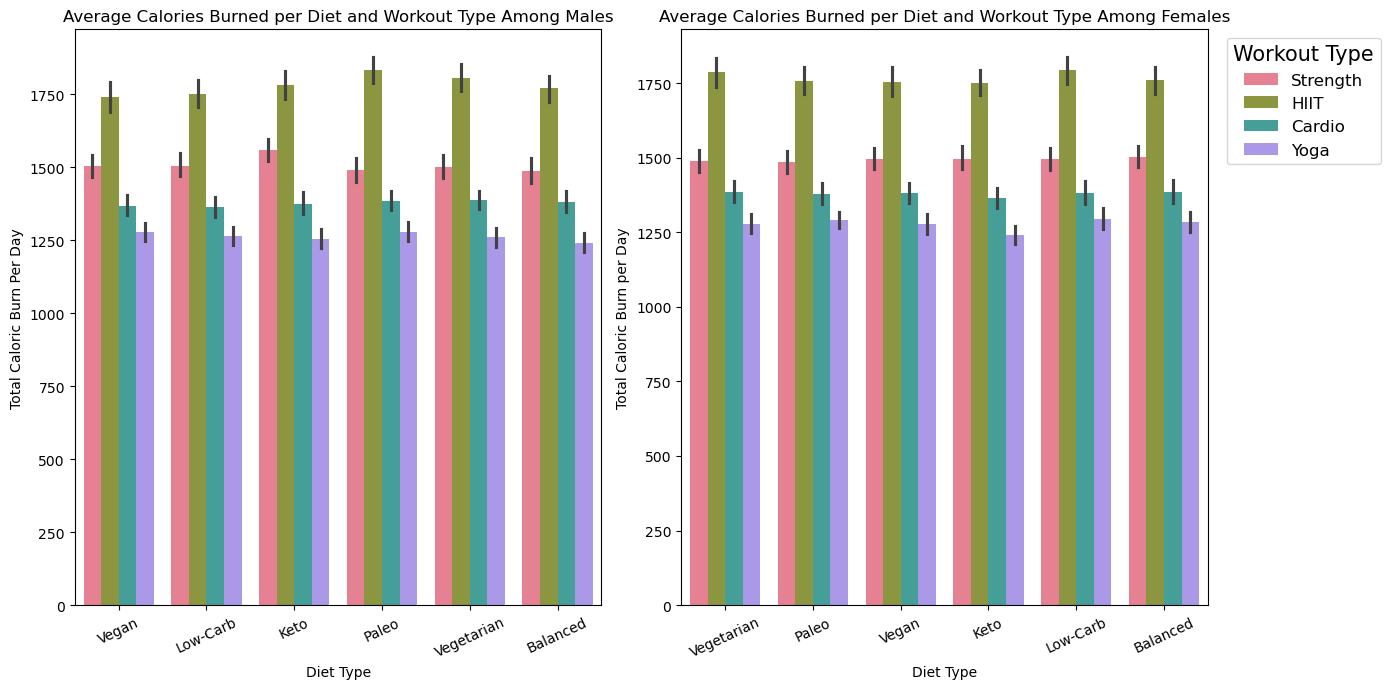

In [191]:
plt.figure(figsize = (14,7))

    # Male plot
plt.subplot(1,2,1)
sns.barplot(
    data = male_cals_data,
    x = 'diet_type',
    y = 'Calories_Burned',
    hue = 'Workout_Type',
    estimator = 'mean',
    errorbar = 'ci', palette = 'husl', hue_order = calories_filtered_q3['Workout_Type'].unique()) 
    # hue_order to make sure the legend matches for both plots (and the one above)
plt.title("Average Calories Burned per Diet and Workout Type Among Males")
plt.xlabel('Diet Type')
plt.ylabel("Total Caloric Burn Per Day")
plt.xticks(rotation = 25)
plt.legend([], [], frameon = False)


    # Female plot
plt.subplot(1,2,2)
sns.barplot(
    data = female_cals_data,
    x = 'diet_type',
    y = 'Calories_Burned',
    hue = 'Workout_Type',
    estimator = 'mean',
    errorbar = 'ci', palette = 'husl', hue_order = calories_filtered_q3['Workout_Type'].unique())
plt.title("Average Calories Burned per Diet and Workout Type Among Females")
plt.xlabel('Diet Type')
plt.ylabel("Total Caloric Burn per Day")
plt.xticks(rotation = 25)
plt.legend([], [], frameon = False)


# Creating a global legend for gender
plt.legend(title = "Workout Type", title_fontsize = 15, fontsize = 12, bbox_to_anchor = (1.02, 1), loc = "upper left")
plt.tight_layout()
plt.show()


In [192]:
# Summary table of the barplots above
combined = pd.concat([male_cals_data, female_cals_data])

summary_q3 = combined.groupby(['Gender', 'diet_type', 'Workout_Type'])['Calories_Burned'].agg(
    mean = 'mean',
    median = 'median',
    count = 'count',
    std = 'std'
).reset_index()

# Calculating 95% confidence interval manually (formula look up online)
summary_q3['standard_error'] = summary_q3['std'] / np.sqrt(summary_q3['count'])

summary_q3['CI_lower'] = summary_q3['mean'] - 1.96 * summary_q3['standard_error']
summary_q3['CI_upper'] = summary_q3['mean'] + 1.96 * summary_q3['standard_error']

# Table to incorporate into report
summary_q3 = summary_q3[['Gender', 'diet_type', 'Workout_Type',
                         'mean', 'median', 'count', 'CI_lower', 'CI_upper']]

summary_q3


,Gender,diet_type,Workout_Type,mean,median,count,CI_lower,CI_upper
0,Female,Balanced,Cardio,1385.476014,1276.000,281,1347.912856,1423.039172
1,Female,Balanced,HIIT,1759.093304,1677.800,345,1714.190863,1803.995746
2,Female,Balanced,Strength,1502.956884,1394.630,353,1466.769375,1539.144392
3,Female,Balanced,Yoga,1285.045644,1306.610,101,1251.628107,1318.463180
4,Female,Keto,Cardio,1364.096346,1266.140,312,1331.172702,1397.019991
5,Female,Keto,HIIT,1750.175995,1654.690,392,1705.795088,1794.556902
6,Female,Keto,Strength,1496.018630,1392.040,365,1459.354226,1532.683034
7,Female,Keto,Yoga,1241.319279,1242.110,111,1210.119937,1272.518622
8,Female,Low-Carb,Cardio,1380.676165,1287.470,279,1344.500153,1416.852177
9,Female,Low-Carb,HIIT,1792.549263,1704.220,353,1746.839106,1838.259420
